In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report



df = pd.read_csv("../emnist_combined_letters.csv")

print(f"Combined shape: {df.shape}")

Combined shape: (103598, 785)


In [3]:
df.head()

,label,p0,p1,p2,p3,p4,p5,p6,p7,p8,...,p774,p775,p776,p777,p778,p779,p780,p781,p782,p783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Ignorerar första elementet, alltså label och i y använder bara label

x = df.iloc[:, 1:]
y = df.iloc[:, 0]
y = y - 1


print("Features shape:", x.shape)
print("Target shape: ", y.shape)

Features shape: (103598, 784)
Target shape:  (103598,)


In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")

Train samples: 82878
Test samples: 20720


In [6]:
from pathlib import Path


lettermodel_path = Path("../trained_models/xgboost_lettermodel.json")

In [7]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=26,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

model.fit(x_train, y_train)

print("Training complete!")

Training complete!


In [8]:
predictions = model.predict(x_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")


print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.8893 (88.93%)

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       839
           1       0.91      0.91      0.91       839
           2       0.94      0.93      0.94       844
           3       0.90      0.89      0.89       840
           4       0.94      0.93      0.94       848
           5       0.93      0.93      0.93       839
           6       0.78      0.74      0.76       837
           7       0.89      0.91      0.90       845
           8       0.69      0.72      0.70       846
           9       0.90      0.92      0.91       840
          10       0.93      0.91      0.92       848
          11       0.71      0.72      0.72       843
          12       0.96      0.95      0.95       840
          13       0.88      0.92      0.90       833
          14       0.91      0.96      0.93       842
          15       0.94      0.95      0.94       846
          16       0.76      0.

In [9]:
model.save_model("xgboost_lettermodel.json")

## Can be used later by using xgb.XGBClassifier()
## E.g model = xgb.XGBClassifier()
##      model.load_model("xgboost_lettermodel.json")



In [10]:
pred = model.predict(x_test[:10])

print("Prediction:", pred)
print("Actual:", y_test[:10].values)

Prediction: [ 7 17 16  4 22 13  9 14  6  1]
Actual: [ 7 17 16  4 22 13  9 14  6  1]


In [11]:
print(sorted(y.unique())[:30])

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]


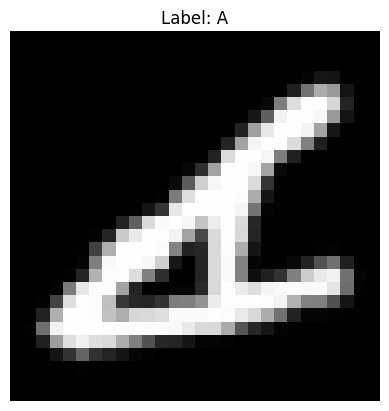

In [12]:
import matplotlib.pyplot as plt
import numpy as np

index = 0

image = x.iloc[index].values.reshape(28, 28)
label = y.iloc[index]

plt.imshow(image, cmap="gray")
plt.title(f"Label: {chr(label + 65)}")
plt.axis("off")
plt.show()